In [8]:
import numpy as np
import tifffile
from sklearn.cluster import KMeans
import io
import matplotlib.pyplot as plt
from PIL import Image

from IPython.display import Image as IPyImage, display
from helper import *

In [9]:
tiff_path = "Greyscale/EFSGP01_00.tif"

with tifffile.TiffFile(tiff_path) as tif:
    shape = tif.series[0].shape
    print(f"Image dimensions: {shape}")
    print(f"Data type: {tif.series[0].dtype}")
        
    depth, height, width = shape
            
    print(f"Depth (Z): {depth}, Height (Y): {height}, Width (X): {width}")

Image dimensions: (1600, 1400, 1400)
Data type: uint16
Depth (Z): 1600, Height (Y): 1400, Width (X): 1400


In [10]:
region, (start_z, start_y, start_x) = read_voxel_region(tiff_path)
np.unique(region)

Reading region: Z[717:817], Y[678:778], X[607:707]


array([10984, 11037, 11177, ..., 52432, 52489, 52564], dtype=uint16)

In [11]:
def normalize_image(imgs):
    
    # on garde que les valeurs positives pour la normalisation
    positive_vals = imgs[imgs > 0]
    mu = np.mean(positive_vals)
    sigma = np.std(positive_vals)
    
    # on mets la normalisation 
    norm_imgs = (imgs - mu) / (5 * sigma)
    
    # Remettre à zéro les valeurs initialement nulles
    norm_imgs[imgs == 0] = 0
    return norm_imgs

data_normalized = normalize_image(region)
np.unique(data_normalized)

array([-0.45860109, -0.45772135, -0.45539749, ...,  0.2293928 ,
        0.23033894,  0.23158387])

In [12]:
voxels = data_normalized.flatten().reshape(-1, 1)

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(voxels)

# Reshape back to original volume
segmented = labels.reshape(data_normalized.shape)

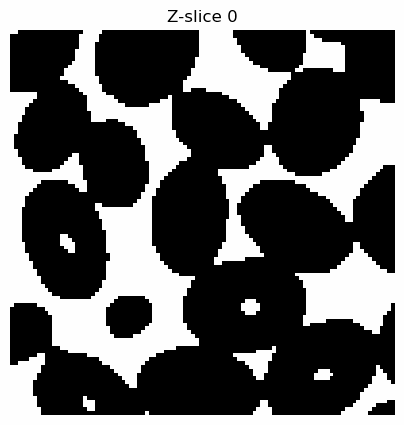

In [14]:
def display_gif(zone):
    slice_indices = list(range(zone.shape[0]))  # Use actual depth if != 100
    frames = []
    for slice_idx in slice_indices:
        fig, ax = plt.subplots(figsize=(5, 5))
        im = ax.imshow(zone[slice_idx], cmap='gray', interpolation='nearest')
        ax.set_title(f'Z-slice {slice_idx}')
        ax.axis('off')
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        frame = Image.open(buf)  # <- use PIL.Image here
        frames.append(frame)

    # Save as GIF in-memory
    gif_buf = io.BytesIO()
    frames[0].save(
        gif_buf,
        format='GIF',
        save_all=True,
        append_images=frames[1:],
        duration=100,
        loop=0
    )
    gif_buf.seek(0)

    # Display in notebook
    display(IPyImage(data=gif_buf.read()))

display_gif(segmented)